In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

# Load CSV  for benin-malanville
df = pd.read_csv("../data/togo-dapaong_qc.csv")
print("Shape:", df.shape)
print(df.info())
print(df.describe())
print(df.isna().sum())
# Only fill NaN for numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# If you want to drop columns that are all NaN, like 'Comments':
df = df.drop(columns=['Comments'])


Shape: (525600, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525600 entries, 0 to 525599
Data columns (total 19 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Timestamp      525600 non-null  object 
 1   GHI            525600 non-null  float64
 2   DNI            525600 non-null  float64
 3   DHI            525600 non-null  float64
 4   ModA           525600 non-null  float64
 5   ModB           525600 non-null  float64
 6   Tamb           525600 non-null  float64
 7   RH             525600 non-null  float64
 8   WS             525600 non-null  float64
 9   WSgust         525600 non-null  float64
 10  WSstdev        525600 non-null  float64
 11  WD             525600 non-null  float64
 12  WDstdev        525600 non-null  float64
 13  BP             525600 non-null  int64  
 14  Cleaning       525600 non-null  int64  
 15  Precipitation  525600 non-null  float64
 16  TModA          525600 non-null  float64
 17  TModB    

In [2]:
# 5️⃣ Detect outliers
df['z_GHI'] = zscore(df['GHI'])
df = df[df['z_GHI'].abs() < 3]
print(df)
df.drop(columns=['z_GHI'], inplace=True)


               Timestamp  GHI  DNI  DHI  ModA  ModB  Tamb    RH   WS  WSgust  \
0       2021-10-25 00:01 -1.3  0.0  0.0   0.0   0.0  24.8  94.5  0.9     1.1   
1       2021-10-25 00:02 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.1     1.6   
2       2021-10-25 00:03 -1.3  0.0  0.0   0.0   0.0  24.8  94.4  1.2     1.4   
3       2021-10-25 00:04 -1.2  0.0  0.0   0.0   0.0  24.8  94.3  1.2     1.6   
4       2021-10-25 00:05 -1.2  0.0  0.0   0.0   0.0  24.8  94.0  1.3     1.6   
...                  ...  ...  ...  ...   ...   ...   ...   ...  ...     ...   
525595  2022-10-24 23:56 -0.8  0.0  0.0   0.0   0.0  25.2  53.8  0.0     0.0   
525596  2022-10-24 23:57 -0.9  0.0  0.0   0.0   0.0  25.3  53.5  0.0     0.0   
525597  2022-10-24 23:58 -1.0  0.0  0.0   0.0   0.0  25.3  53.4  0.0     0.0   
525598  2022-10-24 23:59 -1.1  0.0  0.0   0.0   0.0  25.4  53.5  0.0     0.0   
525599  2022-10-25 00:00 -1.2  0.0  0.0   0.0   0.0  25.4  52.3  0.0     0.0   

        WSstdev     WD  WDstdev   BP  C

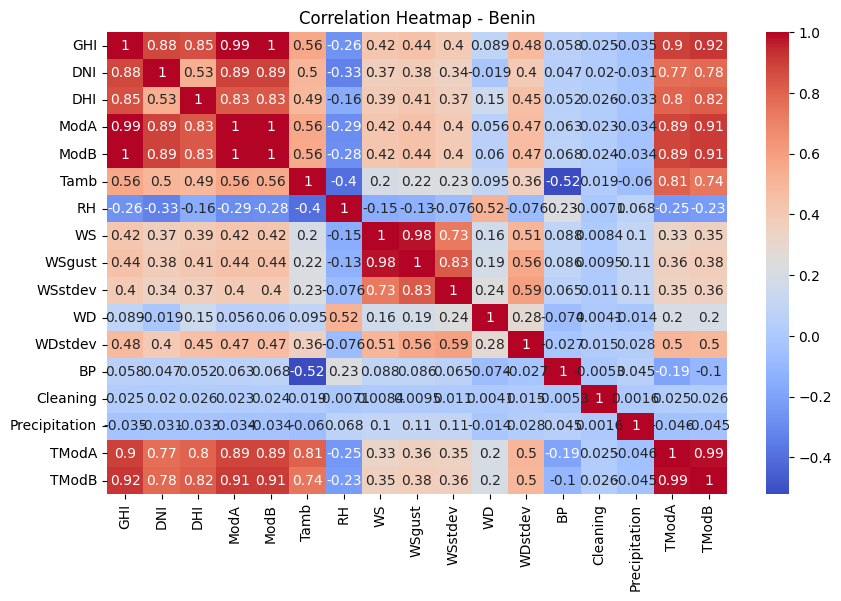

                    GHI       DNI       DHI      ModA      ModB      Tamb  \
GHI            1.000000  0.876939  0.851603  0.994949  0.995421  0.563581   
DNI            0.876939  1.000000  0.531292  0.889367  0.889383  0.504922   
DHI            0.851603  0.531292  1.000000  0.832473  0.832085  0.490215   
ModA           0.994949  0.889367  0.832473  1.000000  0.999563  0.562020   
ModB           0.995421  0.889383  0.832085  0.999563  1.000000  0.557077   
Tamb           0.563581  0.504922  0.490215  0.562020  0.557077  1.000000   
RH            -0.259804 -0.329203 -0.156051 -0.288716 -0.281783 -0.400518   
WS             0.421799  0.366476  0.390421  0.420388  0.421614  0.197112   
WSgust         0.444011  0.384653  0.410330  0.442593  0.443626  0.221067   
WSstdev        0.399664  0.343188  0.366777  0.398525  0.398964  0.227071   
WD             0.088880 -0.018949  0.153388  0.056099  0.060027  0.094773   
WDstdev        0.479464  0.397268  0.454252  0.472605  0.472210  0.361336   

In [3]:
# Select only numeric columns for the correlation heatmap
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap - Benin')
plt.show()
# Get and print the full correlation matrix for all numeric columns
corr_matrix = numeric_cols.corr()
print(corr_matrix)

In [4]:
# Get numeric correlation matrix
corr_matrix = numeric_cols.corr()

# Calculate average absolute correlation for each variable (excluding self, the diagonal)
average_corr = corr_matrix.apply(lambda row: (row.drop(row.name).abs().mean()), axis=1)
print(average_corr)


GHI              0.519495
DNI              0.448650
DHI              0.450147
ModA             0.516979
ModB             0.516873
Tamb             0.395456
RH               0.214989
WS               0.351125
WSgust           0.373180
WSstdev          0.342930
WD               0.147200
WDstdev          0.358019
BP               0.107181
Cleaning         0.015608
Precipitation    0.049300
TModA            0.516817
TModB            0.515688
dtype: float64


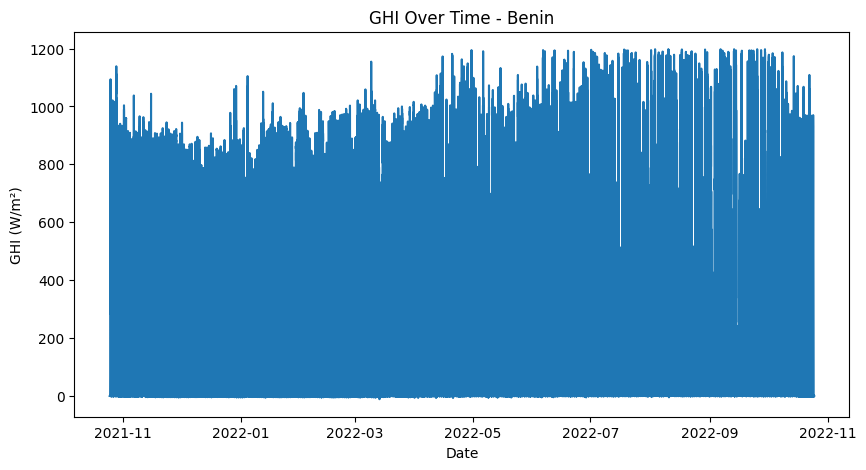

In [5]:
# 8️⃣ Plot GHI over time
plt.figure(figsize=(10,5))
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
plt.plot(df['Timestamp'], df['GHI'])
plt.title('GHI Over Time - Benin')
plt.xlabel('Date')
plt.ylabel('GHI (W/m²)')
plt.show()

# 9️⃣ Export cleaned data
df.to_csv('../data/benin_clean.csv', index=False)